In [1]:
%pip install seaborn
%pip install plotly


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib
import urllib.request
import sys 
sys.path.append('/Users/luisfuentes/Library/Python/3.9/lib/python/site-packages')
import seaborn as sns
import plotly.express as px

/Users/luisfuentes/miniconda3/envs/ml_env/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/Users/luisfuentes/miniconda3/envs/ml_env/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
df_1 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_012_health_indicators_BRFSS2021.csv")
df_2 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_binary_5050split_health_indicators_BRFSS2021.csv")
df_3 = pd.read_csv("https://raw.githubusercontent.com/lasyaharini-cloud/Diabetes-Prediction/main/data/diabetes_binary_health_indicators_BRFSS2021.csv")

Analysis for Diabetes_012 dataset....
The number of variable:  22
The dependent variable:  Diabetes_012
The explanatory variables:
 ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


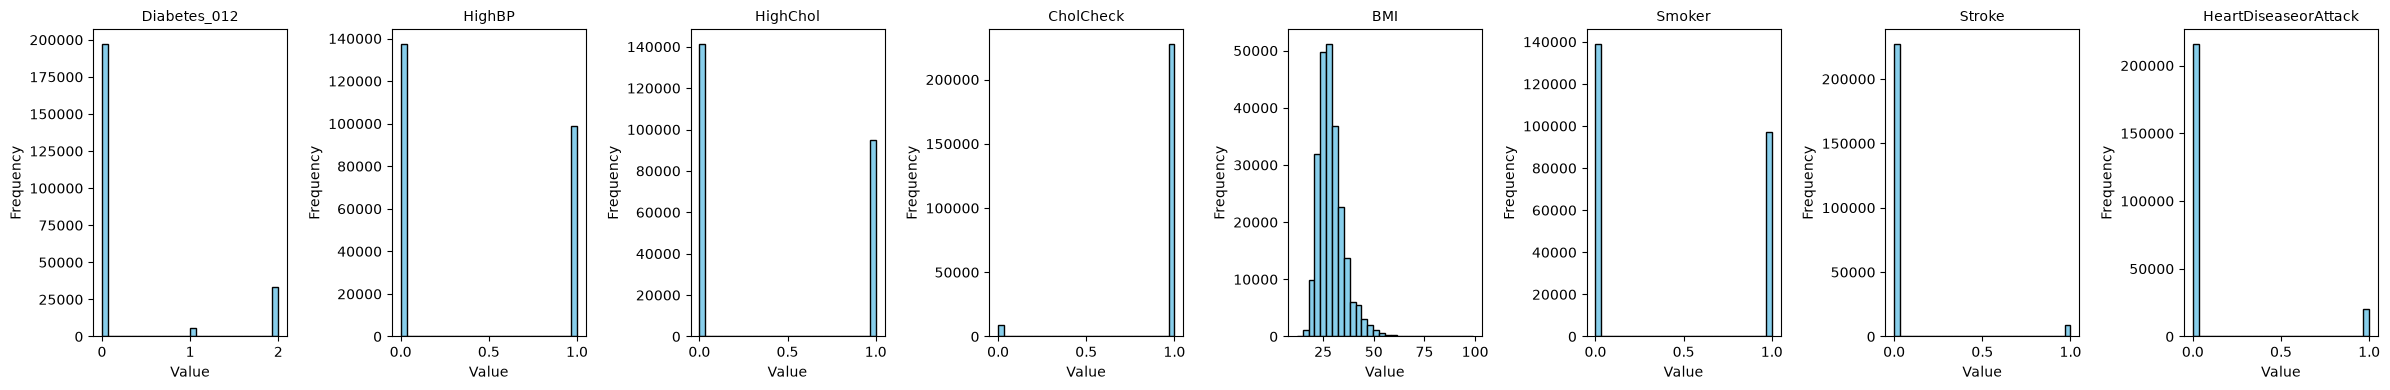

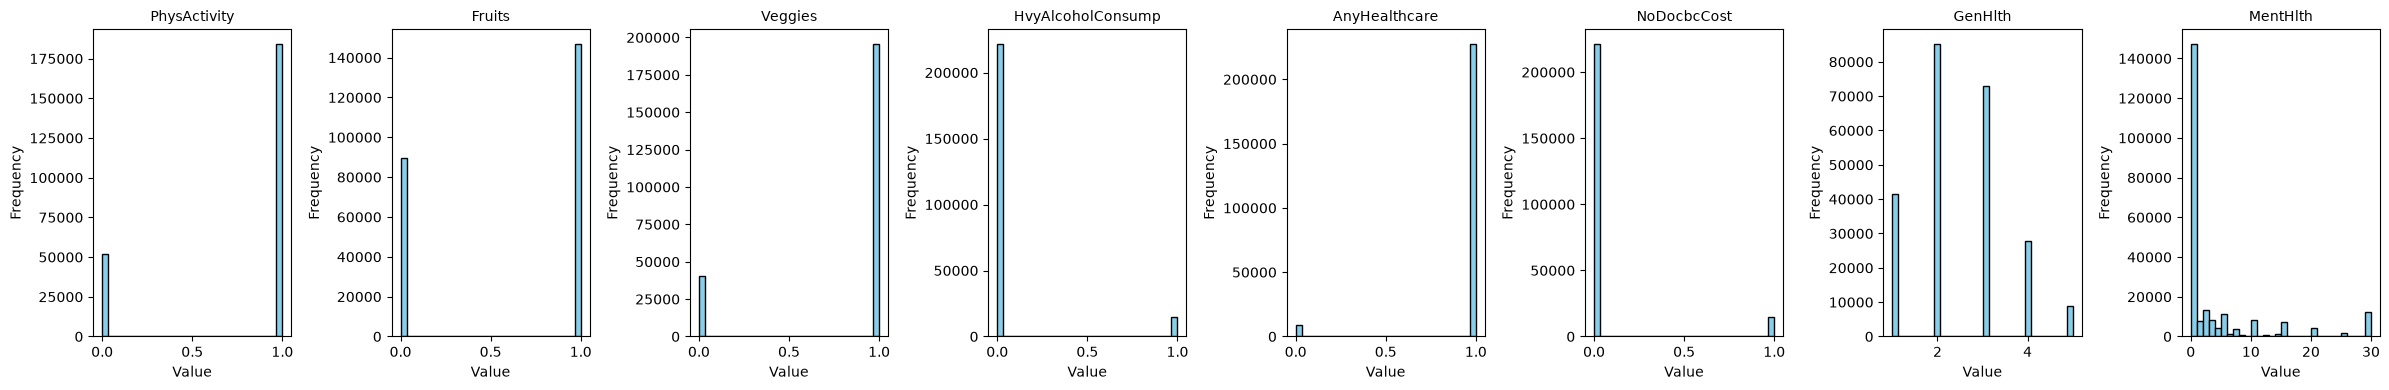

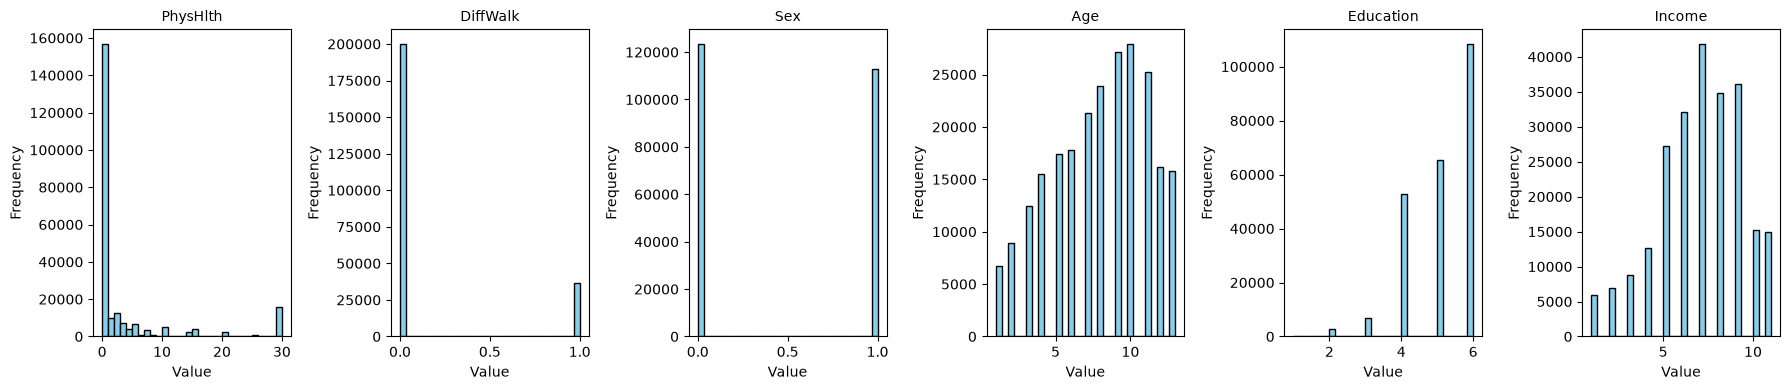

In [3]:
y = df_1["Diabetes_012"]
x = df_1.iloc[:,1:]

print("Analysis for Diabetes_012 dataset....")
print(f"The number of variable: ", len(df_1.columns))
print(f"The dependent variable: ", df_1.columns[0])
print(f"The explanatory variables:\n", list(x.columns))
#print(f"The column names:\n" + "\n".join(df_1.columns))

num_plots = 3 
cols = list(df_1.columns)

chunk_size = int(np.ceil(len(cols) / num_plots))

for i in range(0, len(cols), chunk_size):
    cols_chunk = cols[i : i + chunk_size]
    n_sub = len(cols_chunk)

    fig, axes = plt.subplots(1, n_sub, figsize=(3 * n_sub, 4))
    axes = np.atleast_1d(axes)

    for ax, var_name in zip(axes, cols_chunk):
        ax.hist(
            df_1[var_name], bins=30, color="skyblue", edgecolor="black"
        )
        ax.set_title(var_name, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [4]:
print("Binary variable proportion:\n")
binary = []
table = {}

summary = x.describe()

for i in x.columns:
    if summary.loc["50%", i] in (0, 1) and summary.loc["max", i] == 1:
        count = round((x[i].eq(0).sum() / len(x[i])) * 100, 2)
        binary.append(i)
        table[i] = {
            "0s": count,
            "1s": round(100 - count, 2)
        }
        print(f"{i}= 0s: {count}% and 1s: {round(100 - count, 2)}%")  

table = pd.DataFrame(table)



Binary variable proportion:

HighBP= 0s: 58.14% and 1s: 41.86%
HighChol= 0s: 59.79% and 1s: 40.21%
CholCheck= 0s: 3.67% and 1s: 96.33%
Smoker= 0s: 58.8% and 1s: 41.2%
Stroke= 0s: 96.11% and 1s: 3.89%
HeartDiseaseorAttack= 0s: 91.35% and 1s: 8.65%
PhysActivity= 0s: 22.08% and 1s: 77.92%
Fruits= 0s: 37.87% and 1s: 62.13%
Veggies= 0s: 17.22% and 1s: 82.78%
HvyAlcoholConsump= 0s: 93.79% and 1s: 6.21%
AnyHealthcare= 0s: 3.74% and 1s: 96.26%
NoDocbcCost= 0s: 93.63% and 1s: 6.37%
DiffWalk= 0s: 84.61% and 1s: 15.39%
Sex= 0s: 52.22% and 1s: 47.78%


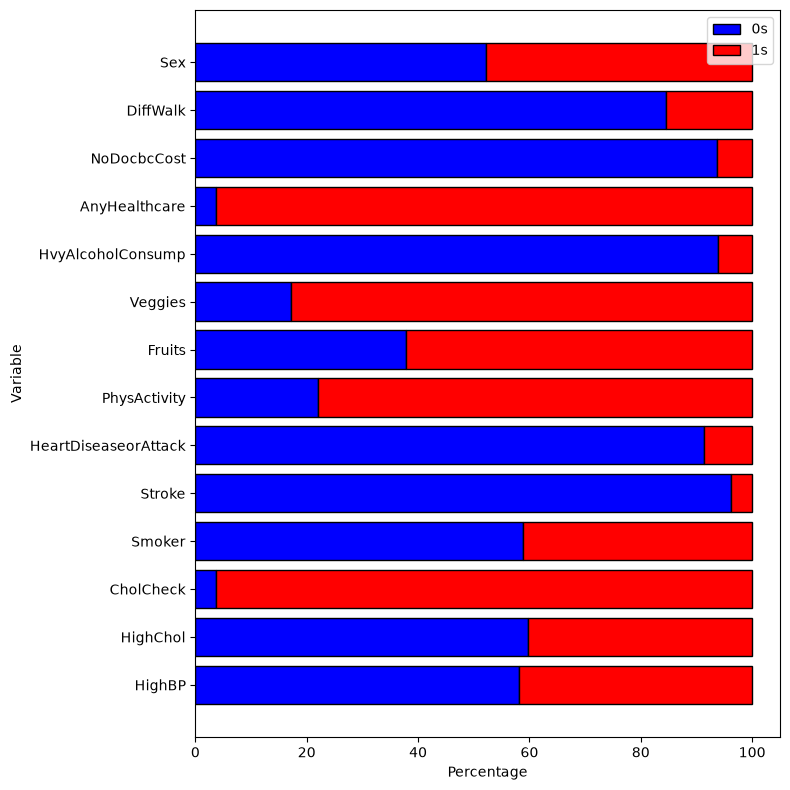

In [5]:
cat1 = table.iloc[0:1, :]
cat2 = table.iloc[1:, :]

columns = table.columns
y_pos = np.arange(len(columns))

fig, ax = plt.subplots(figsize=(8, 0.5 * len(columns) + 1))

ax.barh(y_pos, cat1.iloc[0].values, color="blue", edgecolor="black", label="0s")
ax.barh(y_pos, cat2.iloc[0].values, left=cat1.iloc[0].values, color="red", edgecolor="black", label="1s")

ax.set_yticks(y_pos)
ax.set_yticklabels(columns)
ax.set_xlabel("Percentage")
ax.set_ylabel("Variable")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
binary.append('Diabetes_012')
df_1_mod = df_1.loc[:, [col for col in binary if col in df_1.columns]]



In [ ]:
binary.append('Diabetes_012')
df_1_mod = df_1.loc[:, [col for col in binary if col in df_1.columns]]

variables = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

df_long = df_1_mod.melt(
    id_vars="Diabetes_012",
    value_vars=variables,
    var_name="Variable",
    value_name="Value"
)

# Count observations
counts = (
    df_long
    .groupby(["Variable", "Diabetes_012", "Value"])
    .size()
    .reset_index(name="Count")
)

fig = px.bar(
    counts,
    x="Diabetes_012",
    y="Count",
    color="Value",
    facet_col="Variable",
    facet_col_wrap=6,
    #barmode="group",
    text="Count",
    category_orders={
        "Diabetes_012": [0.0, 1.0, 2.0],
        "Value": [0.0, 1.0]
    },
    labels={
        "Diabetes_012": "Diabetes class",
        "Count": "Number of observations",
        "Value": "Variable value"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    height=1200,
    width=1200)

fig.show()

Analysis for Diabetes_binary_50/50....
The number of variable:  22
The dependent variable:  Diabetes_binary
The explanatory variables:
 ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


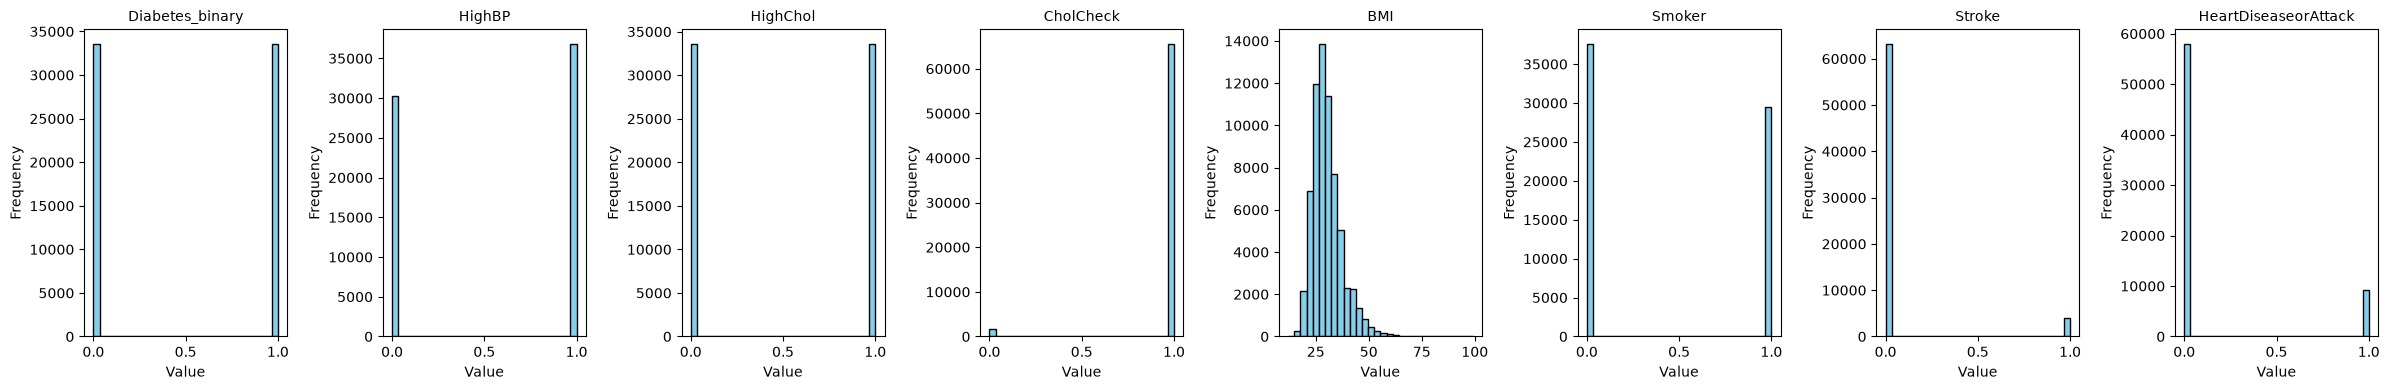

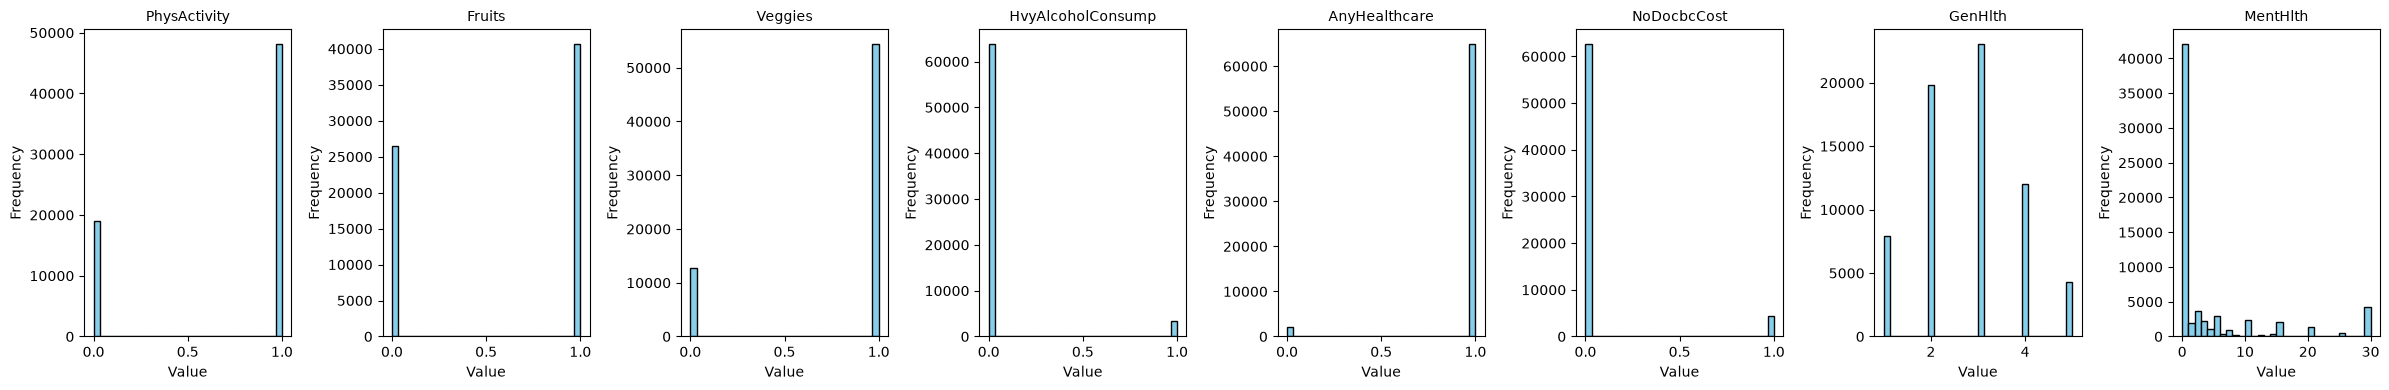

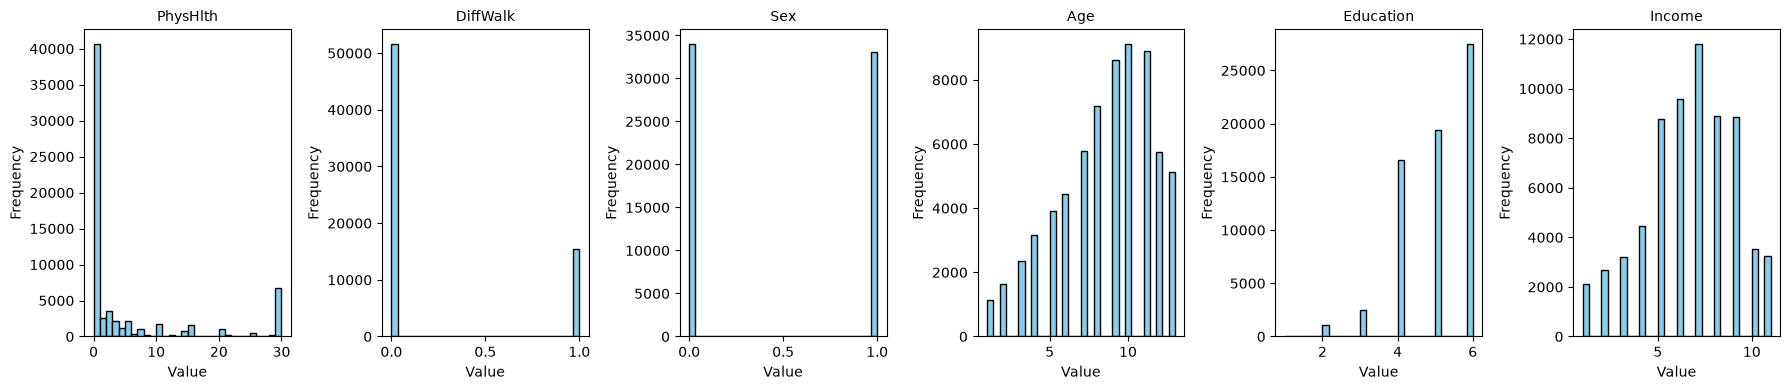

In [31]:
y = df_2["Diabetes_binary"]
x = df_2.iloc[:,1:]

print("Analysis for Diabetes_binary_50/50....")
print(f"The number of variable: ", len(df_2.columns))
print(f"The dependent variable: ", df_2.columns[0])
print(f"The explanatory variables:\n", list(x.columns))
#print(f"The column names:\n" + "\n".join(df_1.columns))

num_plots = 3 
cols = list(df_2.columns)

chunk_size = int(np.ceil(len(cols) / num_plots))

for i in range(0, len(cols), chunk_size):
    cols_chunk = cols[i : i + chunk_size]
    n_sub = len(cols_chunk)

    fig, axes = plt.subplots(1, n_sub, figsize=(3 * n_sub, 4))
    axes = np.atleast_1d(axes)

    for ax, var_name in zip(axes, cols_chunk):
        ax.hist(
            df_2[var_name], bins=30, color="skyblue", edgecolor="black"
        )
        ax.set_title(var_name, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [41]:
print("Binary variable proportion:\n")
binary = []
table = {}

summary = x.describe()

for i in x.columns:
    if summary.loc["50%", i] in (0, 1) and summary.loc["max", i] == 1:
        count = round((x[i].eq(0).sum() / len(x[i])) * 100, 2)
        binary.append(i)
        table[i] = {
            "0s": count,
            "1s": round(100 - count, 2)
        }
        print(f"{i}= 0s: {count}% and 1s: {round(100 - count, 2)}%")  

table = pd.DataFrame(table)

Binary variable proportion:

HighBP= 0s: 45.17% and 1s: 54.83%
HighChol= 0s: 49.98% and 1s: 50.02%
CholCheck= 0s: 2.38% and 1s: 97.62%
Smoker= 0s: 55.98% and 1s: 44.02%
Stroke= 0s: 94.11% and 1s: 5.89%
HeartDiseaseorAttack= 0s: 86.34% and 1s: 13.66%
PhysActivity= 0s: 28.27% and 1s: 71.73%
Fruits= 0s: 39.41% and 1s: 60.59%
Veggies= 0s: 18.94% and 1s: 81.06%
HvyAlcoholConsump= 0s: 95.09% and 1s: 4.91%
AnyHealthcare= 0s: 3.27% and 1s: 96.73%
NoDocbcCost= 0s: 93.35% and 1s: 6.65%
DiffWalk= 0s: 76.88% and 1s: 23.12%
Sex= 0s: 50.66% and 1s: 49.34%


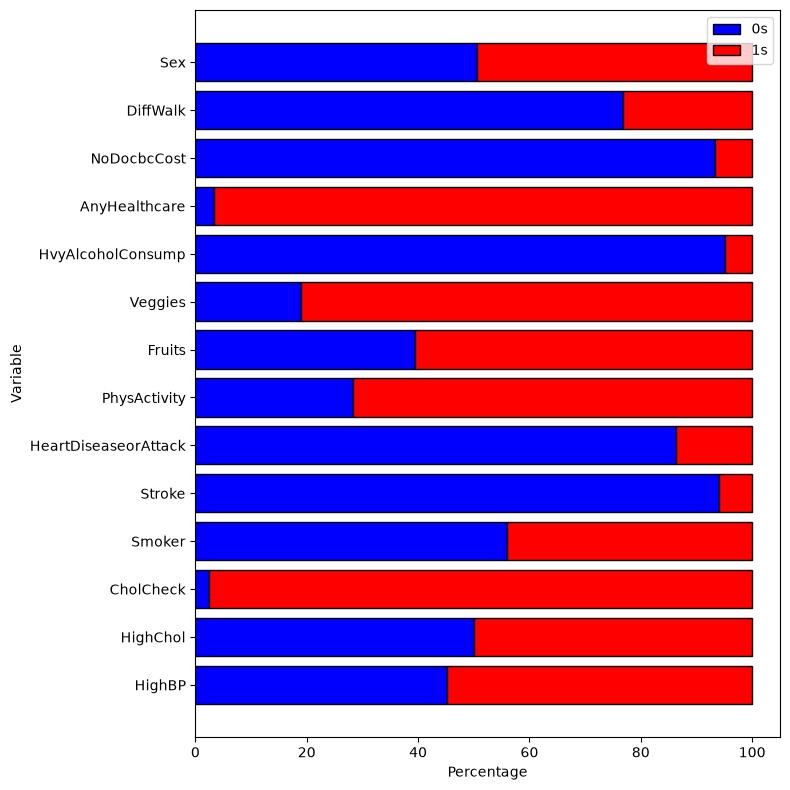

In [36]:
cat1 = table.iloc[0:1, :]
cat2 = table.iloc[1:, :]

columns = table.columns
y_pos = np.arange(len(columns))

fig, ax = plt.subplots(figsize=(8, 0.5 * len(columns) + 1))

ax.barh(y_pos, cat1.iloc[0].values, color="blue", edgecolor="black", label="0s")
ax.barh(y_pos, cat2.iloc[0].values, left=cat1.iloc[0].values, color="red", edgecolor="black", label="1s")

ax.set_yticks(y_pos)
ax.set_yticklabels(columns)
ax.set_xlabel("Percentage")
ax.set_ylabel("Variable")
ax.legend()

plt.tight_layout()
plt.show()

In [42]:
binary.append('Diabetes_binary')
df_2_mod = df_2.loc[:, [col for col in binary if col in df_2.columns]]

variables = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

df_long = df_2_mod.melt(
    id_vars="Diabetes_binary",
    value_vars=variables,
    var_name="Variable",
    value_name="Value"
)

# Count observations
counts = (
    df_long
    .groupby(["Variable", "Diabetes_binary", "Value"])
    .size()
    .reset_index(name="Count")
)

fig = px.bar(
    counts,
    x="Diabetes_binary",
    y="Count",
    color="Value",
    facet_col="Variable",
    facet_col_wrap=6,
    #barmode="group",
    text="Count",
    category_orders={
        "Diabetes_binary": [0.0, 1.0],
        "Value": [0.0, 1.0]
    },
    labels={
        "Diabetes_binary": "Diabetes class",
        "Count": "Number of observations",
        "Value": "Variable value"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    height=1200,
    width=1200)

fig.show()

Analysis for Diabetes_binary_health_indicators....
The number of variable:  22
The dependent variable:  Diabetes_binary
The explanatory variables:
 ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


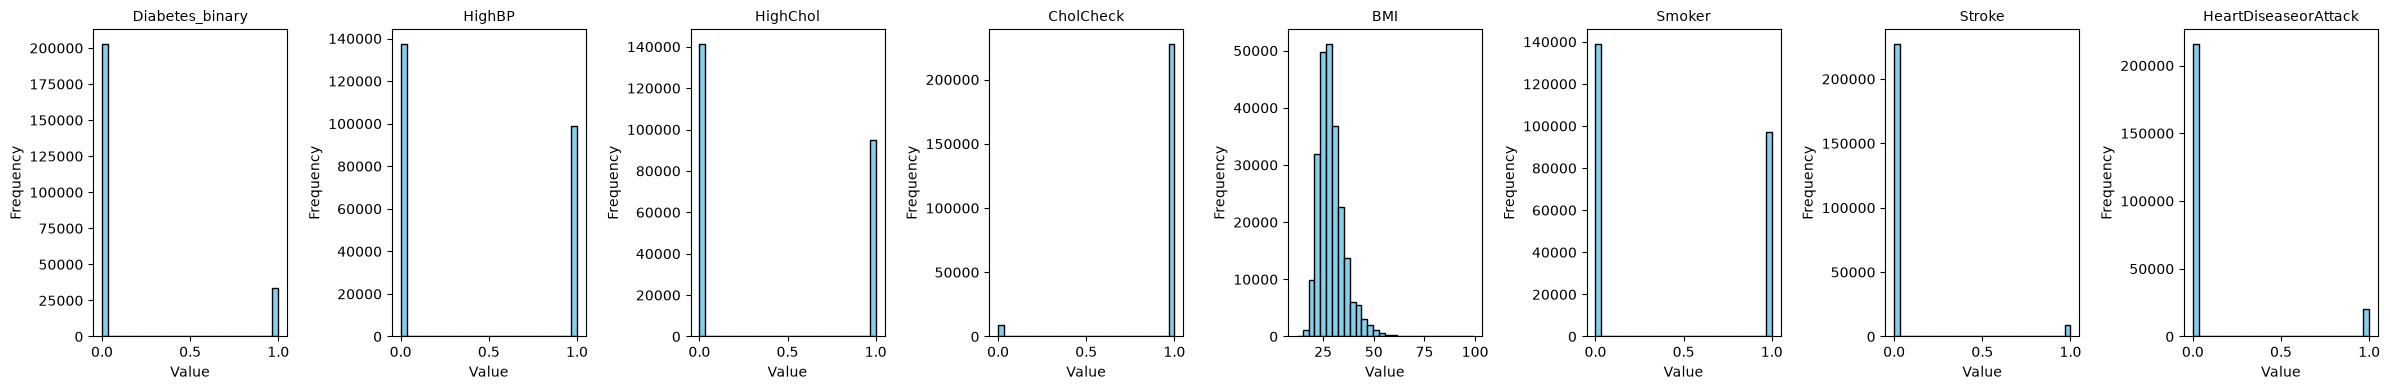

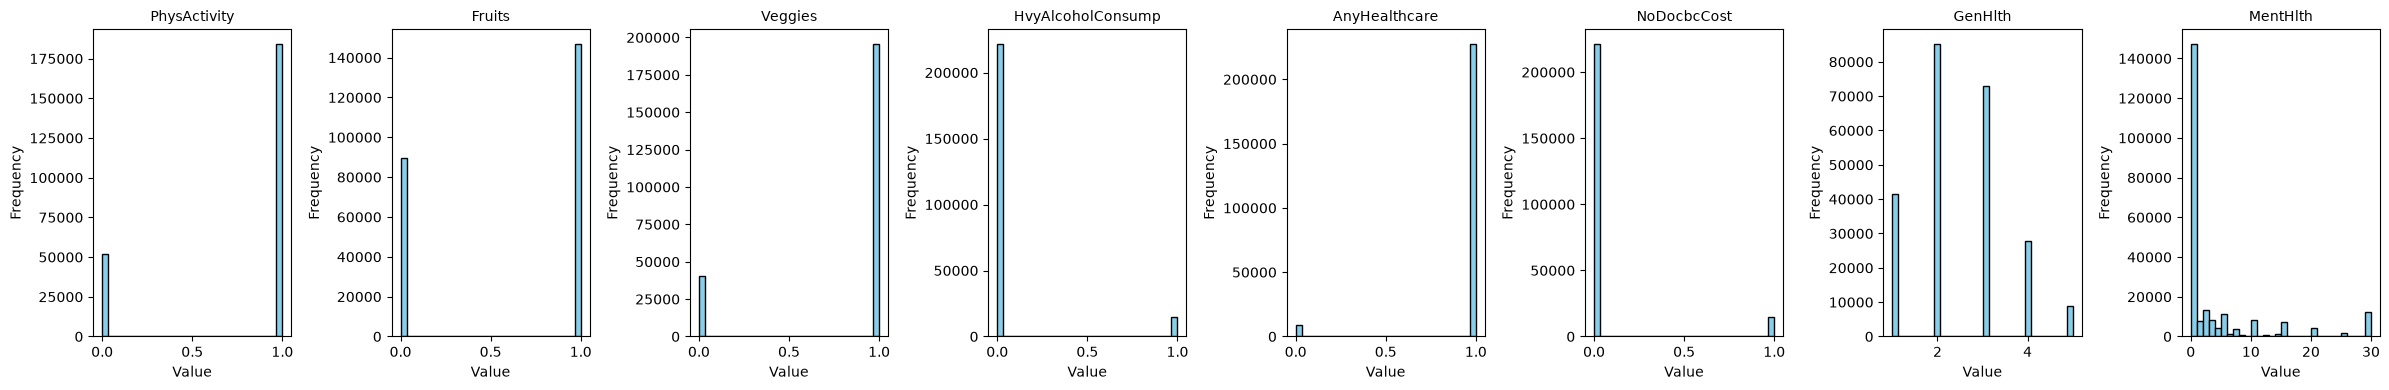

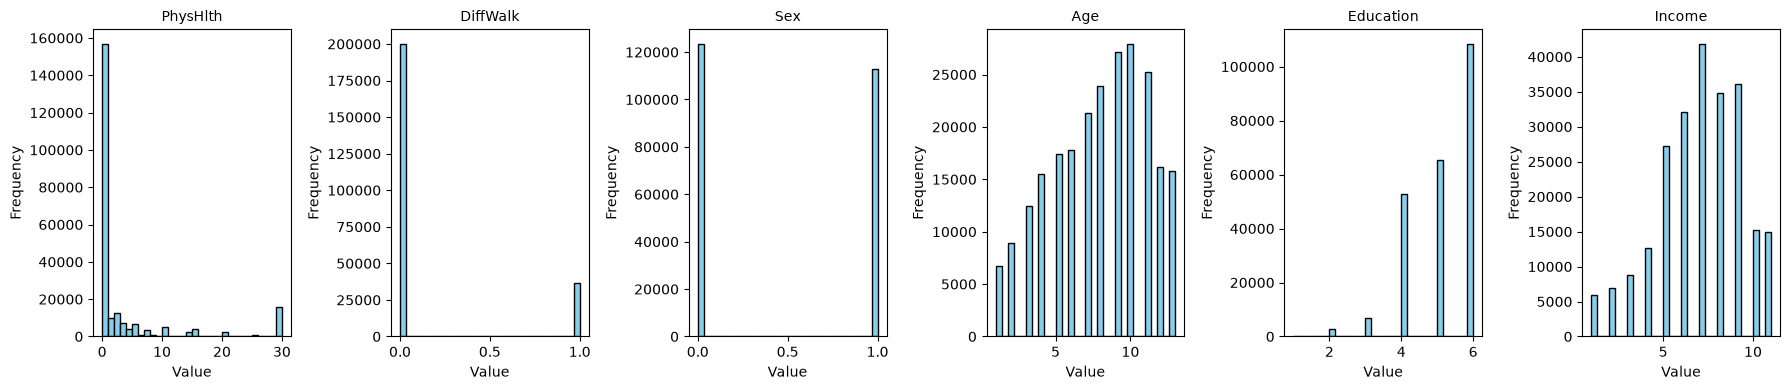

In [43]:
y = df_3["Diabetes_binary"]
x = df_3.iloc[:,1:]

print("Analysis for Diabetes_binary_health_indicators....")
print(f"The number of variable: ", len(df_3.columns))
print(f"The dependent variable: ", df_3.columns[0])
print(f"The explanatory variables:\n", list(x.columns))
#print(f"The column names:\n" + "\n".join(df_1.columns))

num_plots = 3 
cols = list(df_3.columns)

chunk_size = int(np.ceil(len(cols) / num_plots))

for i in range(0, len(cols), chunk_size):
    cols_chunk = cols[i : i + chunk_size]
    n_sub = len(cols_chunk)

    fig, axes = plt.subplots(1, n_sub, figsize=(3 * n_sub, 4))
    axes = np.atleast_1d(axes)

    for ax, var_name in zip(axes, cols_chunk):
        ax.hist(
            df_3[var_name], bins=30, color="skyblue", edgecolor="black"
        )
        ax.set_title(var_name, fontsize=10)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [44]:
print("Binary variable proportion:\n")
binary = []
table = {}

summary = x.describe()

for i in x.columns:
    if summary.loc["50%", i] in (0, 1) and summary.loc["max", i] == 1:
        count = round((x[i].eq(0).sum() / len(x[i])) * 100, 2)
        binary.append(i)
        table[i] = {
            "0s": count,
            "1s": round(100 - count, 2)
        }
        print(f"{i}= 0s: {count}% and 1s: {round(100 - count, 2)}%")  

table = pd.DataFrame(table)

Binary variable proportion:

HighBP= 0s: 58.14% and 1s: 41.86%
HighChol= 0s: 59.79% and 1s: 40.21%
CholCheck= 0s: 3.67% and 1s: 96.33%
Smoker= 0s: 58.8% and 1s: 41.2%
Stroke= 0s: 96.11% and 1s: 3.89%
HeartDiseaseorAttack= 0s: 91.35% and 1s: 8.65%
PhysActivity= 0s: 22.08% and 1s: 77.92%
Fruits= 0s: 37.87% and 1s: 62.13%
Veggies= 0s: 17.22% and 1s: 82.78%
HvyAlcoholConsump= 0s: 93.79% and 1s: 6.21%
AnyHealthcare= 0s: 3.74% and 1s: 96.26%
NoDocbcCost= 0s: 93.63% and 1s: 6.37%
DiffWalk= 0s: 84.61% and 1s: 15.39%
Sex= 0s: 52.22% and 1s: 47.78%


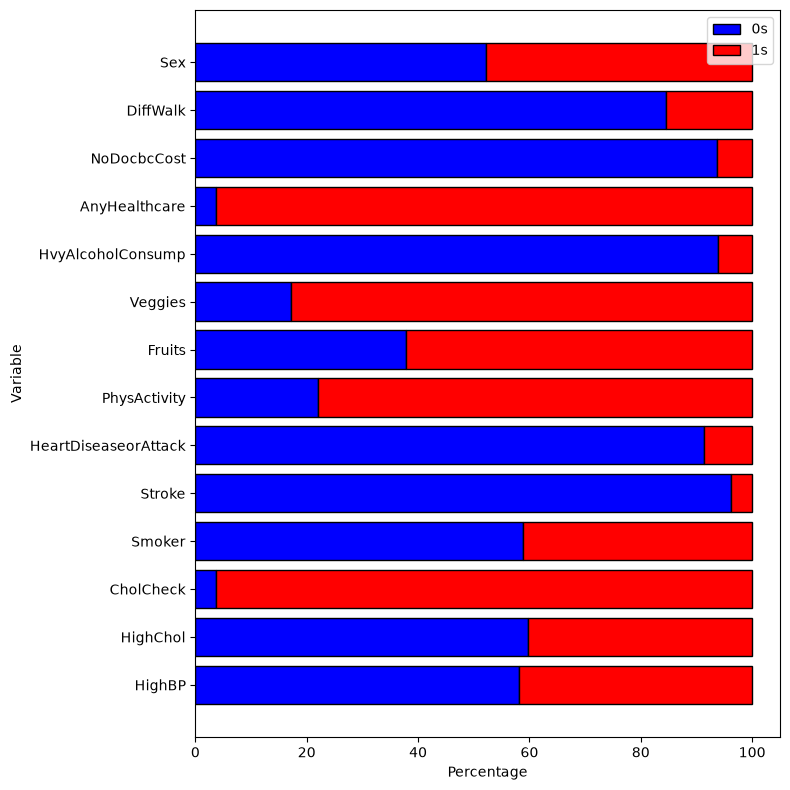

In [45]:
cat1 = table.iloc[0:1, :]
cat2 = table.iloc[1:, :]

columns = table.columns
y_pos = np.arange(len(columns))

fig, ax = plt.subplots(figsize=(8, 0.5 * len(columns) + 1))

ax.barh(y_pos, cat1.iloc[0].values, color="blue", edgecolor="black", label="0s")
ax.barh(y_pos, cat2.iloc[0].values, left=cat1.iloc[0].values, color="red", edgecolor="black", label="1s")

ax.set_yticks(y_pos)
ax.set_yticklabels(columns)
ax.set_xlabel("Percentage")
ax.set_ylabel("Variable")
ax.legend()

plt.tight_layout()
plt.show()

In [46]:
binary.append('Diabetes_binary')
df_3_mod = df_3.loc[:, [col for col in binary if col in df_3.columns]]

variables = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

df_long = df_3_mod.melt(
    id_vars="Diabetes_binary",
    value_vars=variables,
    var_name="Variable",
    value_name="Value"
)

# Count observations
counts = (
    df_long
    .groupby(["Variable", "Diabetes_binary", "Value"])
    .size()
    .reset_index(name="Count")
)

fig = px.bar(
    counts,
    x="Diabetes_binary",
    y="Count",
    color="Value",
    facet_col="Variable",
    facet_col_wrap=6,
    #barmode="group",
    text="Count",
    category_orders={
        "Diabetes_binary": [0.0, 1.0],
        "Value": [0.0, 1.0]
    },
    labels={
        "Diabetes_binary": "Diabetes class",
        "Count": "Number of observations",
        "Value": "Variable value"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    height=1200,
    width=1200)

fig.show()

## Class Imbalance Investigation
Compare the response-class distribution for the balanced binary, imbalanced binary, and 3-class datasets.

In [ ]:
datasets = {
    "Balanced binary":      (df_2, "Diabetes_binary"),
    "Imbalanced binary":    (df_3, "Diabetes_binary"),
    "Imbalanced 3-class":   (df_1, "Diabetes_012"),
}

rows = []
for name, (df, target) in datasets.items():
    counts = df[target].value_counts().sort_index()
    majority = counts.max()
    minority = counts.min()
    for cls, n in counts.items():
        rows.append({
            "Dataset": name,
            "Class": int(cls),
            "Count": n,
            "Percent": round(n / len(df) * 100, 2),
            "Ratio vs. majority": round(majority / n, 2),   # 1.00 for the majority class
        })

imbalance_table = pd.DataFrame(rows)
print(imbalance_table.to_string(index=False))

# Overall imbalance ratio per dataset: majority count / minority count
overall = (
    imbalance_table.groupby("Dataset")["Count"]
    .agg(lambda c: round(c.max() / c.min(), 2))
    .rename("Overall imbalance ratio (max/min)")
)
print()
print(overall)

In [ ]:
class_labels = {
    "Balanced binary":      {0: "No diabetes / Prediabetes", 1: "Diabetes"},
    "Imbalanced binary":    {0: "No diabetes / Prediabetes", 1: "Diabetes"},
    "Imbalanced 3-class":   {0: "No diabetes", 1: "Prediabetes", 2: "Diabetes"},
}

class_colors = {0: "blue", 1: "red", 2: "green"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for ax, (name, sub) in zip(axes, imbalance_table.groupby("Dataset", sort=False)):
    labels = [f"{class_labels[name][c]}\n(class {c})" for c in sub["Class"]]
    colors = [class_colors[c] for c in sub["Class"]]
    bars = ax.bar(labels, sub["Percent"], color=colors, edgecolor="black")
    ax.bar_label(bars, labels=[f"{p:.1f}%" for p in sub["Percent"]], padding=3)
    ax.set_title(name)
    ax.set_ylim(0, 100)

axes[0].set_ylabel("Percentage of observations")
fig.suptitle("Response class distribution", y=1.02)
plt.tight_layout()
plt.show()